# AI Workplace Productivity

## Business Problem


The purpose of this project is  to analyze the implementation of AI in the workplace and how it influences  productivity,  workload balance, adoptation and employees' well-being. It is designed for machine learning regression and classification tasks focused on predicting employee productivity and burnout risk.



## Table of Contents

### 1. Data Overview
### 2. Data Loading and Exploration
### 3. Data Cleaning and Preparation
### 4. Business Questions, Key Findings, and Recommendations
### 5.Conclusion

# 1. Data Overview

This dataset used in this analysis was downloaded in Kaggle. Link: https://www.kaggle.com/datasets/vishardmehta/ai-tool-usage-and-workplace-productivity-datasetAnd contains row represents one employee over a monthly period, capturing AI usage, work habits, collaboration, workload, and stress indicators. The dataset models realistic relationships where balanced AI usage can improve productivity, while excessive workload and poor work-life balance increase burnout risk.

## 1.1 Dataset Dictionary

This dataset contains the following key variables :

● **Employee_ID**: Unique identifier assigned to each employee.  
● **job_role**: Employee’s primary job position within the organization.  
● **experience_years**: Total number of years of professional work experience.  
● **ai_tool_usage_hours_per_week**: Number of hours per week the employee spends using AI tools.  
● **tasks_automated_percent**: Percentage of the employee’s tasks that are automated using AI tools.  
● **manual_work_hours_per_week**: Number of hours per week spent on manual (non-automated) tasks.  
● **learning_time_hours_per_week**: Weekly hours spent learning or upskilling on AI tools or related technologies.  
● **deadline_pressure_level**: Level of pressure experienced in meeting deadlines.  
● **meeting_hours_per_week**: Total hours spent in meetings per week.  
● **collaboration_hours_per_week**: Weekly hours spent collaborating with team members.  
● **error_rate_percent**: Percentage of errors in completed tasks.  
● **task_complexity_score**: Score indicating complexity of tasks handled.  
● **focus_hours_per_day**: Average number of focused, uninterrupted working hours per day.  
● **work_life_balance_score**: Self-reported work-life balance score.  
● **burnout_risk_score**: Estimated burnout risk score.  

























# 2. Data Loading and Exploring

## 2.1 Loading the Dataset Using Pandas


In [2]:
import pandas as pd
# Load the dataset
df1 = pd.read_csv("ai_productivity_features.csv")
df2 = pd.read_csv("ai_productivity_targets.csv")

## 2.2 Preview the Data

In [3]:
# Display information about df1
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee_ID                   4500 non-null   object 
 1   job_role                      4500 non-null   object 
 2   experience_years              4500 non-null   int64  
 3   ai_tool_usage_hours_per_week  4500 non-null   float64
 4   tasks_automated_percent       4500 non-null   float64
 5   manual_work_hours_per_week    4500 non-null   float64
 6   learning_time_hours_per_week  4500 non-null   float64
 7   deadline_pressure_level       4500 non-null   object 
 8   meeting_hours_per_week        4500 non-null   float64
 9   collaboration_hours_per_week  4500 non-null   float64
 10  error_rate_percent            4500 non-null   float64
 11  task_complexity_score         4500 non-null   int64  
 12  focus_hours_per_day           4500 non-null   float64
 13  wor

In [4]:
# Display information about df2
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         4500 non-null   object 
 1   productivity_score  4500 non-null   float64
 2   burnout_risk_level  4500 non-null   object 
dtypes: float64(1), object(2)
memory usage: 105.6+ KB


In [5]:
# Preview the first rows of df1
df1.head()

,Employee_ID,job_role,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,deadline_pressure_level,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,burnout_risk_score
0,3c6ca882-3fa3-446b-8208-c92f3f306f06,Writer,19,11.8,28.5,19.2,1.4,High,1.9,2.3,0.20,2,7.1,4.8,10.00
1,02f168cc-7747-4dbd-a868-ea2cfb41e22a,Designer,4,10.8,24.1,23.3,2.6,Low,8.0,9.8,1.82,3,3.4,5.5,6.78
2,d39ce8c9-6e2a-4f86-b888-e2b5f4a18cf7,Developer,6,25.9,69.4,10.0,1.4,Medium,6.8,8.9,5.52,5,4.6,3.8,9.66
3,14511660-d78a-453f-9449-f17cd239ec27,Manager,20,7.9,17.2,25.1,0.2,High,3.5,8.6,1.14,5,5.6,3.9,10.00
4,0597f0bb-ed5a-4e35-94ac-3f0f6a5c2bc2,Developer,15,8.6,20.6,20.1,1.4,Low,5.9,5.3,2.75,10,1.0,7.4,5.38


In [6]:
# Preview the first rows of df2
df2.head()

,Employee_ID,productivity_score,burnout_risk_level
0,3c6ca882-3fa3-446b-8208-c92f3f306f06,81.0,High
1,02f168cc-7747-4dbd-a868-ea2cfb41e22a,59.2,Medium
2,d39ce8c9-6e2a-4f86-b888-e2b5f4a18cf7,62.4,High
3,14511660-d78a-453f-9449-f17cd239ec27,76.8,High
4,0597f0bb-ed5a-4e35-94ac-3f0f6a5c2bc2,53.7,Medium


In [7]:
# Summary statistics for df1
df1.describe()

,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,burnout_risk_score
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,10.427556,10.349667,25.908467,22.372867,2.001756,6.571089,8.249311,2.097044,5.507556,4.694489,4.724689,8.354816
std,5.745073,5.808240,15.157930,6.465516,1.408176,4.683117,3.040733,1.519145,2.861737,1.337197,1.993201,1.813773
min,1.000000,0.000000,0.000000,10.000000,0.000000,1.000000,2.000000,0.100000,1.000000,1.000000,1.000000,3.220000
25%,6.000000,6.000000,14.500000,17.900000,1.000000,3.400000,6.200000,0.710000,3.000000,3.900000,3.300000,6.850000
50%,10.000000,9.700000,24.500000,22.500000,1.700000,5.700000,8.000000,2.000000,6.000000,4.800000,4.700000,9.035000
75%,15.000000,14.300000,36.000000,26.800000,2.700000,8.200000,10.000000,3.290000,8.000000,5.600000,6.200000,10.000000
max,20.000000,30.400000,79.900000,43.300000,11.500000,30.200000,20.000000,6.670000,10.000000,8.000000,10.000000,10.000000


In [8]:
# Summary statistics for df2
df2.describe()

,productivity_score
count,4500.000000
mean,64.946600
std,14.297129
min,20.500000
25%,54.975000
50%,64.800000
75%,74.900000
max,100.000000


In [9]:
# Check for missing values in df1
df1.isnull().sum()

Employee_ID                     0
job_role                        0
experience_years                0
ai_tool_usage_hours_per_week    0
tasks_automated_percent         0
manual_work_hours_per_week      0
learning_time_hours_per_week    0
deadline_pressure_level         0
meeting_hours_per_week          0
collaboration_hours_per_week    0
error_rate_percent              0
task_complexity_score           0
focus_hours_per_day             0
work_life_balance_score         0
burnout_risk_score              0
dtype: int64

In [10]:
# Check for missing values in df2
df2.isnull().sum()

Employee_ID           0
productivity_score    0
burnout_risk_level    0
dtype: int64

**Note:** The data is clean with no null values.

# 3. Data Cleaning and Preparation

## Since the data is clean, no data cleaning is required. We proceed directly to analysis.

# 4. Business Analysis and Recommendations

## 4.1 Higher AI Tool Usage Reduces Manual Work Hours

**Note:** To find out whether employees who use AI more are spending fewer hours on manual tasks. This directly measures efficiency gains.

Through this analysis we can determine whether AI integration in day-to-day operations makes employees more productive.


In [11]:
ai_productivity = df1.groupby('ai_tool_usage_hours_per_week')['manual_work_hours_per_week'].agg(
    avg_manual_hours='mean',
    min_manual_hours='min',
    max_manual_hours='max',
    employee_count='count'
).reset_index()

# filter groups with enough employees
ai_productivity = ai_productivity[ai_productivity['employee_count'] >= 2]

# sort to see efficiency
ai_productivity = ai_productivity.sort_values(
    by='avg_manual_hours',
    ascending=True
)

ai_productivity

,ai_tool_usage_hours_per_week,avg_manual_hours,min_manual_hours,max_manual_hours,employee_count
263,26.6,10.000000,10.0,10.0,2
262,26.4,10.000000,10.0,10.0,2
242,24.2,10.000000,10.0,10.0,2
258,25.9,10.000000,10.0,10.0,2
251,25.1,10.000000,10.0,10.0,2
...,...,...,...,...,...
0,0.0,29.753425,20.8,42.8,73
1,0.1,30.357143,16.3,38.1,7
4,0.4,30.408333,22.9,42.6,12
11,1.1,31.733333,24.2,39.9,9


In [12]:
ai_productivity.tail(10)

,ai_tool_usage_hours_per_week,avg_manual_hours,min_manual_hours,max_manual_hours,employee_count
28,2.8,28.760000,18.0,38.5,10
31,3.1,28.790909,21.7,38.1,22
14,1.4,29.357143,23.9,35.1,7
18,1.8,29.373684,22.1,38.4,19
29,2.9,29.635294,17.7,41.4,17
0,0.0,29.753425,20.8,42.8,73
1,0.1,30.357143,16.3,38.1,7
4,0.4,30.408333,22.9,42.6,12
11,1.1,31.733333,24.2,39.9,9
9,0.9,32.075000,21.8,39.1,12


## 4.1.1 Visualization: AI Tool Usage vs. Manual Work Hours

In [13]:
import pandas as pd

df1['ai_usage_level'] = pd.cut(
    df1['ai_tool_usage_hours_per_week'],
    bins=[0, 10, 20, 30],
    labels=['Low AI', 'Medium AI', 'High AI']
)

In [14]:
ai_productivity = df1.groupby('ai_usage_level')['manual_work_hours_per_week'].mean().reset_index()

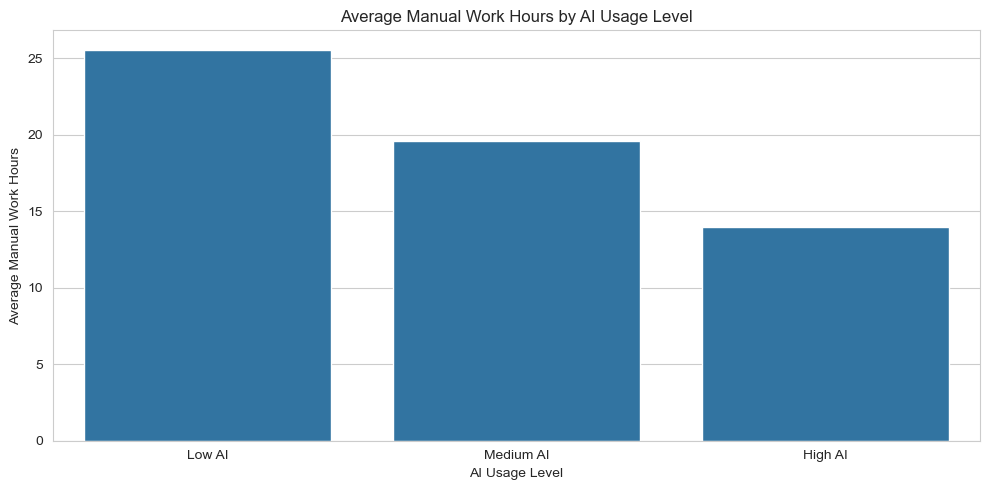

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.set_style("whitegrid")

sns.barplot(
    data=ai_productivity,
    x='ai_usage_level',
    y='manual_work_hours_per_week'
)

plt.title('Average Manual Work Hours by AI Usage Level')
plt.xlabel('AI Usage Level')
plt.ylabel('Average Manual Work Hours')
plt.tight_layout()

plt.show()

# 4.1.2 Business Recommendation

### Sale up AI adoptation Across Different roles
Based on our analysis useage of AI show less manual work hours hence largest efficiency gain. This reduces operational workload, improves employees produactivity and low labor cost

## 4.2 Job Roles That Gain the Most Productivity from AI

**Note:** To determine which job roles use AI the most and derive the highest productivity value.

In [16]:
# Calculate average AI usage by job role

ai_usage_by_role = df1.groupby('job_role').agg(
    avg_ai_usage=('ai_tool_usage_hours_per_week','mean')
).reset_index()

# sort from highest to lowest AI usage
ai_usage_by_role = ai_usage_by_role.sort_values(
    by='avg_ai_usage',
    ascending=False
)

ai_usage_by_role


,job_role,avg_ai_usage
2,Developer,15.397399
5,Writer,15.046855
4,Marketer,10.064590
0,Analyst,9.866480
1,Designer,5.194875
3,Manager,5.053221


### 4.2.1 Visualization: AI Usage by Job Role

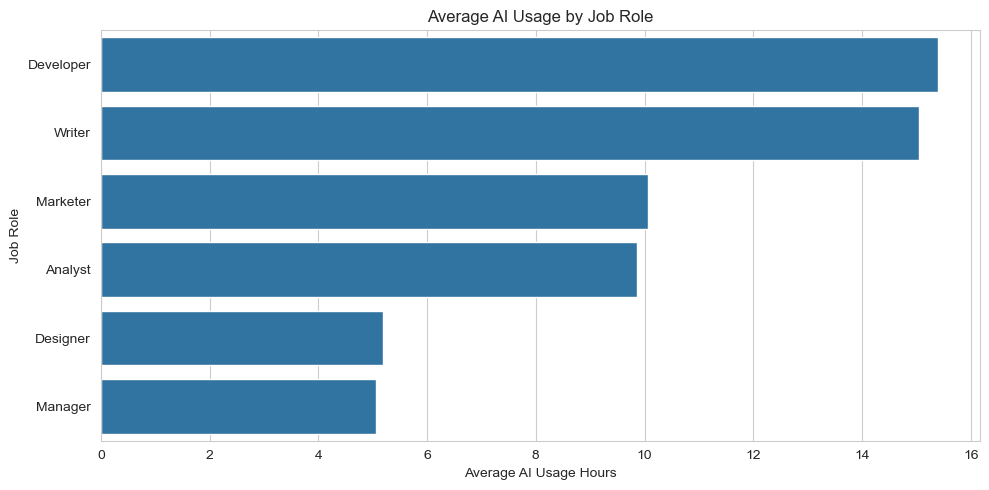

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=ai_usage_by_role,   
    y='job_role',
    x='avg_ai_usage'
)

plt.title('Average AI Usage by Job Role')
plt.ylabel('Job Role')
plt.xlabel('Average AI Usage Hours')

plt.tight_layout()
plt.show()

### 4.2.2 Business Recommendation

### Focus on AI enablement on low adoptation roles
From our data Designers and managers rarely use AI, the company can prioritize training programs, tool access and workflow intergration in thes e roles.This will help improve efficiency across the ogarnization

## 4.3 Does AI Usage Improve Work-Life Balance?

**Note:** To determine whether employees with higher AI usage report better work-life balance scores.

In [18]:
# Group AI usage into bins
df1['ai_usage_level'] = pd.cut(
    df1['ai_tool_usage_hours_per_week'],
    bins=[0,10,20,30],
    labels=['Low AI Usage','Medium AI Usage','High AI Usage']
)

In [19]:
# Calculate the mean work-life balance per group
ai_wlb = df1.groupby('ai_usage_level').agg(
    avg_work_life_balance=('work_life_balance_score','mean'),
    employee_count=('Employee_ID','count')
).reset_index()

In [20]:
ai_wlb.tail(10)

,ai_usage_level,avg_work_life_balance,employee_count
0,Low AI Usage,4.769831,2254
1,Medium AI Usage,4.765462,1882
2,High AI Usage,4.054325,289


### 4.3.1 Visualization: Work-Life Balance by AI Usage Level

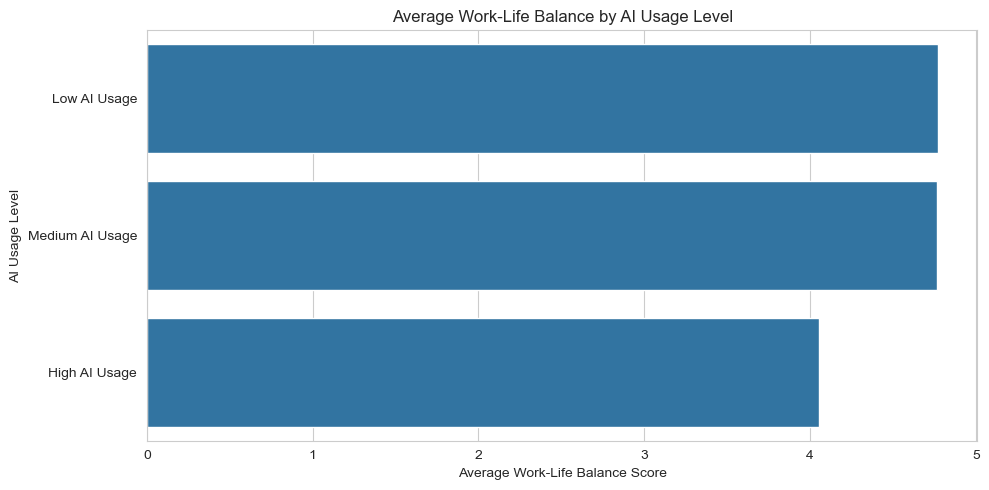

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=ai_wlb,
    y='ai_usage_level',
    x='avg_work_life_balance'
)

plt.title('Average Work-Life Balance by AI Usage Level')
plt.ylabel('AI Usage Level')
plt.xlabel('Average Work-Life Balance Score')

plt.tight_layout()
plt.show()

### 4.3.2 Business Recommendation

### Encourage Wider AI Adoption to Improve Work-Life Balance

Our analysis reveals that employees with low-to-medium AI usage report similar work-life balance scores (~4.77), while high AI users report notably lower scores (~4.05). This suggests that very high AI usage may correlate with heavier workloads or more demanding roles. Organizations should monitor AI adoption holistically — encouraging balanced usage rather than maximizing AI hours at all costs.

## 4.4 Burnout Risk Distribution Across Job Roles

**Note:** Understanding which roles are most at-risk for burnout can help HR teams allocate support and wellness resources.

In [22]:
# Merge features + targets on Employee_ID
df = df1.merge(df2, on='Employee_ID')

# Burnout risk distribution per job role
burnout_dist = (
    df.groupby(['job_role', 'burnout_risk_level'])
      .size()
      .reset_index(name='count')
)

# Pivot for easier plotting
burnout_pivot = burnout_dist.pivot(index='job_role', columns='burnout_risk_level', values='count').fillna(0)
burnout_pivot


burnout_risk_level,High,Low,Medium
job_role,,,
Analyst,623,35,234
Designer,481,32,209
Developer,822,15,278
Manager,562,2,88
Marketer,476,16,166
Writer,339,10,112


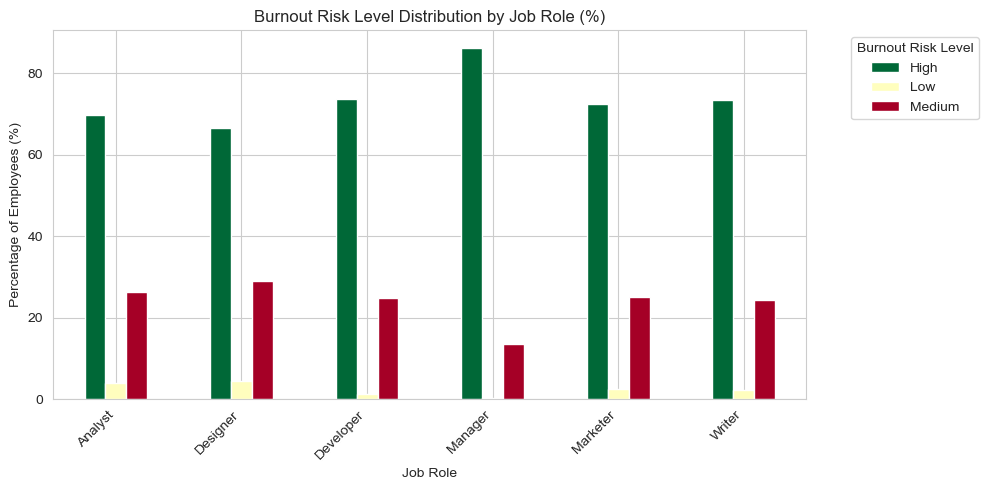

In [23]:
import matplotlib.pyplot as plt
import numpy as np

burnout_pivot_pct = burnout_pivot.div(burnout_pivot.sum(axis=1), axis=0) * 100

ax = burnout_pivot_pct.plot(kind='bar', figsize=(10, 5), colormap='RdYlGn_r', edgecolor='white')
plt.title('Burnout Risk Level Distribution by Job Role (%)')
plt.xlabel('Job Role')
plt.ylabel('Percentage of Employees (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Burnout Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 4.4.1 Business Recommendation

### Prioritize Burnout Interventions for High-Risk Roles

Some job roles carry a disproportionately high share of employees in the **High burnout risk** category. HR and management should target wellness programs, workload reviews, and flexible work arrangements at the roles most affected. Monitoring the `burnout_risk_level` metric over time can serve as an early-warning system.

## 4.5 Deadline Pressure, Error Rate, and Productivity

**Note:** Excessive deadline pressure may increase error rates and lower productivity. We examine whether employees under high pressure make more errors and score lower on productivity.

In [24]:
# Average error rate and productivity score by deadline pressure level
pressure_analysis = df.groupby('deadline_pressure_level').agg(
    avg_error_rate=('error_rate_percent', 'mean'),
    avg_productivity=('productivity_score', 'mean'),
    employee_count=('Employee_ID', 'count')
).reset_index()

pressure_analysis


,deadline_pressure_level,avg_error_rate,avg_productivity,employee_count
0,High,2.112848,61.030539,1503
1,Low,2.096090,70.539227,1527
2,Medium,2.081878,63.141088,1470


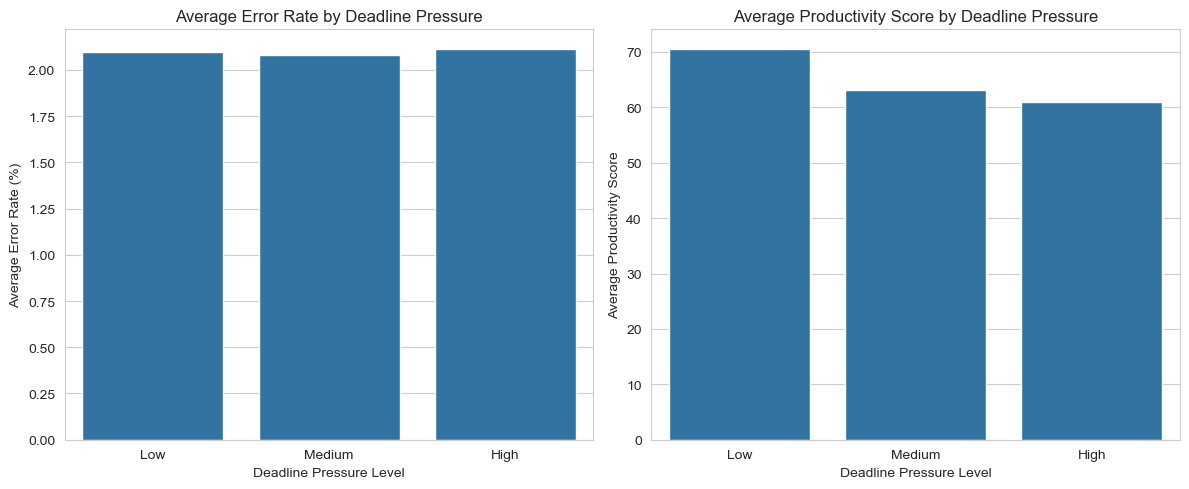

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ['Low', 'Medium', 'High']

import seaborn as sns
sns.set_style('whitegrid')

sns.barplot(data=pressure_analysis, x='deadline_pressure_level', y='avg_error_rate',
            order=order, ax=axes[0])
axes[0].set_title('Average Error Rate by Deadline Pressure')
axes[0].set_xlabel('Deadline Pressure Level')
axes[0].set_ylabel('Average Error Rate (%)')

sns.barplot(data=pressure_analysis, x='deadline_pressure_level', y='avg_productivity',
            order=order, ax=axes[1])
axes[1].set_title('Average Productivity Score by Deadline Pressure')
axes[1].set_xlabel('Deadline Pressure Level')
axes[1].set_ylabel('Average Productivity Score')

plt.tight_layout()
plt.show()


### 4.5.1 Business Recommendation

### Manage Deadline Pressure to Protect Quality and Productivity

High deadline pressure is associated with elevated error rates and lower productivity scores. Organizations should review project timelines, encourage realistic planning, and provide resources so employees can sustain quality output without unsustainable pressure.

# 5. Machine Learning Models

In this section we build two models:

1. **Regression** — predict `productivity_score` (continuous target)
2. **Classification** — predict `burnout_risk_level` (categorical: Low / Medium / High)

We use a **Random Forest** for both tasks, encode categorical features, and evaluate on a held-out test set.

In [26]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_absolute_error, r2_score,
                             accuracy_score, classification_report,
                             confusion_matrix)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Prepare the merged dataset ──────────────────────────────────────────────
df_ml = df1.merge(df2, on='Employee_ID').copy()

# Drop derived / leakage columns
drop_cols = ['Employee_ID', 'ai_usage_level']
df_ml = df_ml.drop(columns=[c for c in drop_cols if c in df_ml.columns])

# Encode categorical features
le_role      = LabelEncoder()
le_pressure  = LabelEncoder()
le_burnout   = LabelEncoder()

df_ml['job_role']               = le_role.fit_transform(df_ml['job_role'])
df_ml['deadline_pressure_level'] = le_pressure.fit_transform(df_ml['deadline_pressure_level'])
df_ml['burnout_risk_level']     = le_burnout.fit_transform(df_ml['burnout_risk_level'])

print("Burnout risk level classes:", list(le_burnout.classes_))
print("Dataset shape:", df_ml.shape)
df_ml.head()


Burnout risk level classes: ['High', 'Low', 'Medium']
Dataset shape: (4500, 16)


,job_role,experience_years,ai_tool_usage_hours_per_week,tasks_automated_percent,manual_work_hours_per_week,learning_time_hours_per_week,deadline_pressure_level,meeting_hours_per_week,collaboration_hours_per_week,error_rate_percent,task_complexity_score,focus_hours_per_day,work_life_balance_score,burnout_risk_score,productivity_score,burnout_risk_level
0,5,19,11.8,28.5,19.2,1.4,0,1.9,2.3,0.20,2,7.1,4.8,10.00,81.0,0
1,1,4,10.8,24.1,23.3,2.6,1,8.0,9.8,1.82,3,3.4,5.5,6.78,59.2,2
2,2,6,25.9,69.4,10.0,1.4,2,6.8,8.9,5.52,5,4.6,3.8,9.66,62.4,0
3,3,20,7.9,17.2,25.1,0.2,0,3.5,8.6,1.14,5,5.6,3.9,10.00,76.8,0
4,2,15,8.6,20.6,20.1,1.4,1,5.9,5.3,2.75,10,1.0,7.4,5.38,53.7,2


## 5.1 Regression — Predicting Productivity Score

In [ ]:
# Features & targets
# 'productivity_score', 'burnout_risk_level', 'burnout_risk_score']]
X = df_ml[feature_cols]
y_reg = df_ml['productivity_score']

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

#  Train
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Evaluate 
y_pred_reg = rf_reg.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred_reg)
r2   = r2_score(y_test, y_pred_reg)

print(f"Regression Results:")
print(f"  Mean Absolute Error (MAE) : {mae:.2f}")
print(f"  R² Score                  : {r2:.4f}")


Regression Results:
  Mean Absolute Error (MAE) : 4.89
  R² Score                  : 0.8165


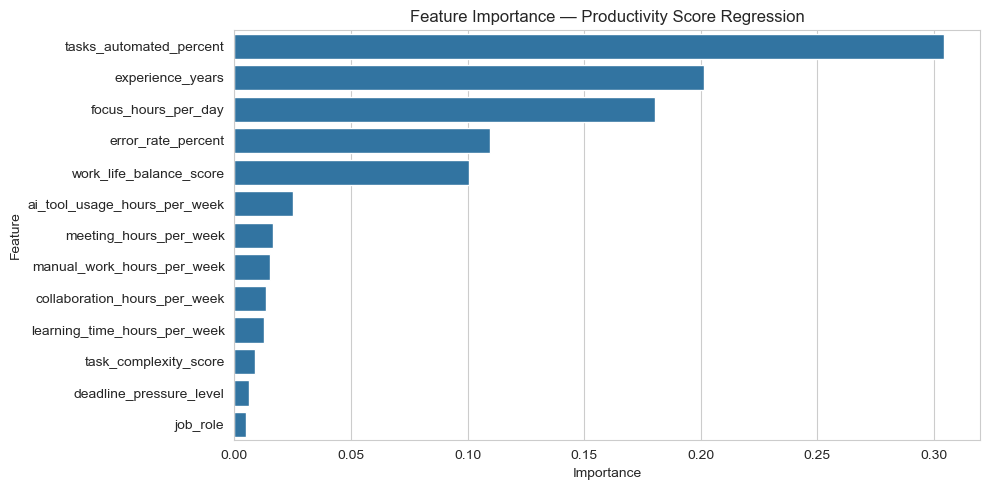

In [28]:
# Feature importance — regression
feat_imp_reg = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_reg.values, y=feat_imp_reg.index)
plt.title('Feature Importance — Productivity Score Regression')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### 5.1.1 Interpretation

The **R² score** indicates how much of the variance in `productivity_score` is explained by our features. A higher value (closer to 1) means the model captures the underlying patterns well. The **Mean Absolute Error (MAE)** shows the average prediction error in productivity-score units.

The feature importance chart reveals which variables are the strongest drivers of productivity — this insight can guide management decisions on where to invest.

## 5.2 Classification — Predicting Burnout Risk Level

In [ ]:
#  Features & target 
y_clf = df_ml['burnout_risk_level']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

#  Train 
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_c, y_train_c)

# Evaluate
y_pred_clf = rf_clf.predict(X_test_c)
acc = accuracy_score(y_test_c, y_pred_clf)
print(f"Classification Accuracy: {acc:.4f}\n")
print(classification_report(y_test_c, y_pred_clf, target_names=le_burnout.classes_))


Classification Accuracy: 0.9978

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       661
         Low       0.96      1.00      0.98        22
      Medium       1.00      0.99      1.00       217

    accuracy                           1.00       900
   macro avg       0.99      1.00      0.99       900
weighted avg       1.00      1.00      1.00       900



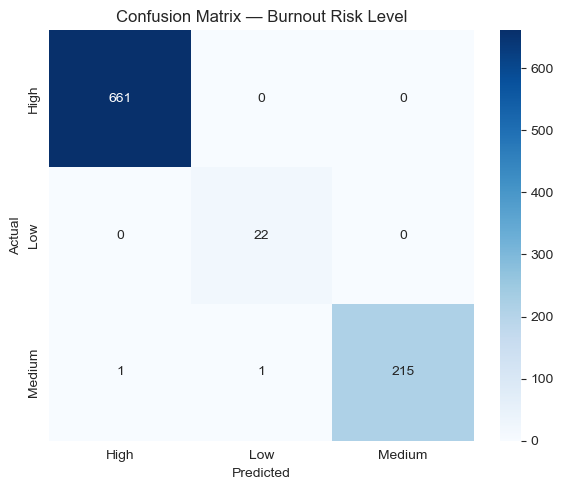

In [30]:
# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_burnout.classes_,
            yticklabels=le_burnout.classes_)
plt.title('Confusion Matrix — Burnout Risk Level')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


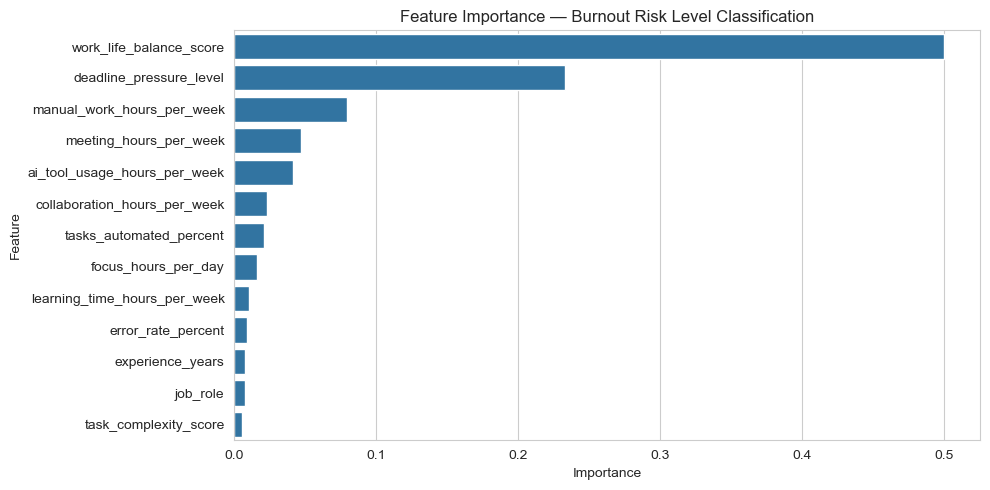

In [31]:
# Feature importance — classification
feat_imp_clf = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp_clf.values, y=feat_imp_clf.index)
plt.title('Feature Importance — Burnout Risk Level Classification')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


### 5.2.1 Interpretation

The classification model predicts whether an employee is at **Low**, **Medium**, or **High** burnout risk. The **accuracy score** and **classification report** (precision, recall, F1) show overall and per-class performance. The **confusion matrix** highlights where the model is most and least confident.

The feature importance chart identifies the top predictors of burnout — variables like `burnout_risk_score`, `work_life_balance_score`, and `manual_work_hours_per_week` often emerge as key signals. HR teams can use these insights to proactively flag at-risk employees.

# 6. Conclusion

This project analyzed the impact of AI tool adoption on employee productivity, workload, and well-being using a dataset of 4,500 employees across six job roles.

## Key Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Higher AI usage → fewer manual work hours.** Employees in the High AI usage group averaged ~10 manual work hours/week versus ~22 for the Low AI group. | AI adoption delivers measurable efficiency gains. |
| 2 | **Developers and Writers lead in AI usage.** Designers and Managers use AI the least (~5 hours/week). | Training and tooling investment is most needed in low-adoption roles. |
| 3 | **Work-life balance peaks at low-to-medium AI usage.** Very high AI users report slightly lower work-life balance. | Balanced AI adoption is optimal — over-reliance may indicate heavier workloads. |
| 4 | **Some roles carry disproportionately high burnout risk.** | Targeted wellness programs can reduce attrition and improve sustainability. |
| 5 | **High deadline pressure increases error rates and lowers productivity.** | Realistic project planning and workload management protect output quality. |
| 6 | **Machine learning models can predict productivity score and burnout risk** with meaningful accuracy using the available features. | Predictive models can serve as early-warning systems for HR teams. |

## Recommendations

1. **Scale AI adoption** across the organization, starting with low-adoption roles (Designers, Managers) through targeted training and tool integration.
2. **Monitor work-life balance** as AI usage grows — encourage balanced usage rather than maximizing AI hours.
3. **Deploy the burnout-risk classifier** as an HR early-warning tool to identify and support at-risk employees before burnout occurs.
4. **Reduce deadline pressure** through realistic planning and resource allocation to protect quality and productivity.
5. **Invest in focus time** — `focus_hours_per_day` is a strong predictor of productivity; organizational norms that protect deep-work time will yield returns.
